In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 安装依赖
# ═══════════════════════════════════════════════════════════
# !pip install torch-geometric --break-system-packages
# PyG 依赖 torch，确保已安装


# ═══════════════════════════════════════════════════════════
# Cell 2 — 导入
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data  import Data, DataLoader
from torch_geometric.nn    import GCNConv, GATConv, global_mean_pool
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import (accuracy_score, f1_score,
                                     roc_auc_score, precision_score,
                                     recall_score)
from sklearn.preprocessing   import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



/opt/anaconda3/envs/KGG/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR = Path("kg_output")
SEED    = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
X_img    = np.load(OUT_DIR / "img_embeddings.npy")
y_bin    = np.load(OUT_DIR / "img_labels.npy")

print(f"Loaded. Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



Loaded. Device: cpu


In [3]:

# ═══════════════════════════════════════════════════════════
# Cell 3 — 构建每个病例的子图（PyG Data 对象）
# 每张图像 → 一个小图：FundusImage + 3个biomarker节点 + Diagnosis + RiskLevel
# ═══════════════════════════════════════════════════════════
import pyarrow.parquet as pq
DATA_DIR = Path("Dataset/Data")

def load_filenames(path):
    df = pq.read_table(path, columns=["filename","annotation"]).to_pandas()
    return df["filename"].tolist(), df["annotation"].tolist()

train_fns, _ = load_filenames(DATA_DIR / "train-00000-of-00001.parquet")
test_fns,  _ = load_filenames(DATA_DIR / "test-00000-of-00001.parquet")
all_fns = train_fns + test_fns

# 节点特征准备
img_nodes  = nodes_df[nodes_df.label=="FundusImage"][["id","filename","annotation"]].rename(columns={"id":"img_id"})
has_diag   = edges_df[edges_df.rel=="HAS_DIAGNOSIS"][["src","dst"]].rename(columns={"src":"img_id","dst":"diag_id"})
has_od     = edges_df[edges_df.rel=="HAS_OPTIC_DISC"][["src","dst"]].rename(columns={"src":"img_id","dst":"od_id"})
has_rim    = edges_df[edges_df.rel=="HAS_RIM"][["src","dst"]].rename(columns={"src":"img_id","dst":"rim_id"})
has_path   = edges_df[edges_df.rel=="HAS_PATHOLOGY"][["src","dst"]].rename(columns={"src":"img_id","dst":"path_id"})

od_cols    = nodes_df[nodes_df.label=="OpticDisc"][["id","cup_to_disc_ratio","sharp_edge"]].rename(columns={"id":"od_id"})
rim_cols   = nodes_df[nodes_df.label=="NeuralRim"][["id","isnt_rule_followed","rim_pallor","rim_thinning"]].rename(columns={"id":"rim_id"})
path_cols  = nodes_df[nodes_df.label=="Pathology"][["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"})
diag_cols  = nodes_df[nodes_df.label=="Diagnosis"][["id","confidence"]].rename(columns={"id":"diag_id"})

master = (img_nodes.merge(has_diag, on="img_id")
                   .merge(has_od,   on="img_id")
                   .merge(has_rim,  on="img_id")
                   .merge(has_path, on="img_id")
                   .merge(od_cols,  on="od_id")
                   .merge(rim_cols, on="rim_id")
                   .merge(path_cols,on="path_id")
                   .merge(diag_cols,on="diag_id", how="left"))

bool_cols = ["sharp_edge","isnt_rule_followed","rim_pallor","rim_thinning",
             "bayoneting","notching","laminar_dot_sign"]
for c in bool_cols:
    master[c] = master[c].map({True:1,False:0,"True":1,"False":0}).fillna(0).astype(float)
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce").fillna(0.0)
master["confidence"]        = pd.to_numeric(master["confidence"],        errors="coerce").fillna(0.9)
master["isnt_violated"]     = 1 - master["isnt_rule_followed"]
master["y"]                 = (master["annotation"] == "glaucoma").astype(int)

# KG chain features
sup_edges    = edges_df[edges_df.rel=="SUPPORTS_RULE"].copy()
rules_df_kg  = nodes_df[nodes_df.label=="ClinicalRule"].copy()
strength_map = {str(r["id"]): str(r["strength"]).strip().lower()
                for _, r in rules_df_kg.iterrows()}
diag_counts  = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    diag_counts[d][strength_map.get(r,"weak")] += 1
chain_recs = [{"diag_id": d,
               "chain_score": c["strong"]*3+c["moderate"]*2+c["weak"],
               "n_strong": c["strong"], "n_moderate": c["moderate"], "n_weak": c["weak"]}
              for d, c in diag_counts.items()]
chain_df = pd.DataFrame(chain_recs)
master   = master.merge(chain_df, on="diag_id", how="left")
for col in ["chain_score","n_strong","n_moderate","n_weak"]:
    master[col] = master[col].fillna(0)

fn_to_master = master.set_index("filename")
fn_to_imgidx = {fn: i for i, fn in enumerate(all_fns)}

# 图像 embedding 降维到 64 dim（PCA，减少节点特征维度）
from sklearn.decomposition import PCA
pca = PCA(n_components=64, random_state=SEED)
X_img_pca = pca.fit_transform(X_img)
scaler_img = StandardScaler()
X_img_pca  = scaler_img.fit_transform(X_img_pca)
print(f"Image PCA: {X_img.shape} → {X_img_pca.shape}")

# 节点特征维度
# FundusImage : 64 (PCA img)
# OpticDisc   : 3  (cdr, sharp_edge, pad)
# NeuralRim   : 4  (isnt_violated, rim_pallor, rim_thinning, pad)
# Pathology   : 3  (bayoneting, notching, laminar_dot_sign)
# Diagnosis   : 4  (confidence, chain_score, n_strong, n_moderate)
NODE_DIM = 64  # 统一填充到同一维度

def pad(arr, dim=NODE_DIM):
    arr = np.array(arr, dtype=np.float32)
    if len(arr) < dim:
        arr = np.concatenate([arr, np.zeros(dim - len(arr))])
    return arr[:dim]

def build_graph(fn, img_idx):
    if fn not in fn_to_master.index:
        return None
    row = fn_to_master.loc[fn]
    y   = int(row["y"])

    # 5个节点：img(0), od(1), rim(2), path(3), diag(4)
    img_feat  = X_img_pca[img_idx]
    od_feat   = pad([row["cup_to_disc_ratio"], row["sharp_edge"], 0.0])
    rim_feat  = pad([row["isnt_violated"], row["rim_pallor"], row["rim_thinning"], 0.0])
    path_feat = pad([row["bayoneting"], row["notching"], row["laminar_dot_sign"]])
    diag_feat = pad([row["confidence"], row["chain_score"]/20.0,
                     row["n_strong"]/10.0, row["n_moderate"]/10.0])

    x = torch.tensor(np.stack([img_feat, od_feat, rim_feat, path_feat, diag_feat]),
                     dtype=torch.float)

    # 边：img→od, img→rim, img→path, img→diag
    # od→diag, rim→diag, path→diag (SUPPORTS_DIAGNOSIS)
    # 双向边
    edge_index = torch.tensor([
        [0,0,0,0, 1,2,3, 1,2,3,4, 0,0,0,0],
        [1,2,3,4, 4,4,4, 0,0,0,0, 1,2,3,4],
    ], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.long))

# 构建所有图
graphs = []
labels = []
for fn in all_fns:
    idx = fn_to_imgidx.get(fn, None)
    if idx is None:
        continue
    g = build_graph(fn, idx)
    if g is not None:
        graphs.append(g)
        labels.append(g.y.item())

labels = np.array(labels)
print(f"Built {len(graphs)} graphs  |  glaucoma={labels.sum()}  normal={(1-labels).sum()}")
print(f"Node features dim: {graphs[0].x.shape}")
print(f"Edges per graph  : {graphs[0].edge_index.shape[1]}")



Image PCA: (689, 2048) → (689, 64)
Built 689 graphs  |  glaucoma=427  normal=262
Node features dim: torch.Size([5, 64])
Edges per graph  : 15


In [4]:

# ═══════════════════════════════════════════════════════════
# Cell 4 — GNN 模型定义
# ═══════════════════════════════════════════════════════════

class GlaucomaGCN(nn.Module):
    """2层 GCN + 全局平均池化 + MLP 分类头"""
    def __init__(self, in_dim=64, hidden=128, out_dim=2, dropout=0.3):
        super().__init__()
        self.conv1   = GCNConv(in_dim, hidden)
        self.conv2   = GCNConv(hidden, hidden)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden, 64)
        self.fc2     = nn.Linear(64, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


class GlaucomaGAT(nn.Module):
    """2层 GAT（注意力机制）+ 全局平均池化 + MLP"""
    def __init__(self, in_dim=64, hidden=64, heads=4, out_dim=2, dropout=0.3):
        super().__init__()
        self.conv1   = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
        self.conv2   = GATConv(hidden*heads, hidden, heads=1, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden, 32)
        self.fc2     = nn.Linear(32, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


print("GCN and GAT models defined.")



GCN and GAT models defined.


In [5]:

# ═══════════════════════════════════════════════════════════
# Cell 5 — 训练 & 评估函数
# ═══════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        prob   = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        pred   = out.argmax(dim=1).cpu().numpy()
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred)
        y_prob.extend(prob)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred,        zero_division=0), 4),
        "AUC":       round(roc_auc_score(y_true, y_prob),  4),
    }

def run_gnn_cv(model_cls, model_kwargs, graphs, labels,
               n_splits=5, epochs=50, lr=1e-3, batch_size=32):
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores  = []
    history = {"train_loss": [], "val_f1": []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(graphs, labels)):
        tr_graphs  = [graphs[i] for i in tr_idx]
        val_graphs = [graphs[i] for i in val_idx]
        tr_loader  = DataLoader(tr_graphs,  batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_graphs, batch_size=batch_size)

        model     = model_cls(**model_kwargs).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        fold_losses, fold_f1s = [], []
        for epoch in range(epochs):
            loss = train_epoch(model, tr_loader, optimizer, criterion)
            fold_losses.append(loss)
            if (epoch + 1) % 10 == 0:
                val_sc = evaluate(model, val_loader)
                fold_f1s.append(val_sc["F1"])

        val_sc = evaluate(model, val_loader)
        scores.append(val_sc)
        history["train_loss"].append(fold_losses)
        history["val_f1"].append(fold_f1s)
        print(f"  Fold {fold+1}: F1={val_sc['F1']:.4f}  AUC={val_sc['AUC']:.4f}")

    return pd.DataFrame(scores).mean().round(4), history

print("Training functions ready.")



Training functions ready.


In [6]:

# ═══════════════════════════════════════════════════════════
# Cell 6 — 运行 GCN 和 GAT
# ═══════════════════════════════════════════════════════════

print("=== Training GCN ===")
gcn_scores, gcn_history = run_gnn_cv(
    GlaucomaGCN,
    {"in_dim": NODE_DIM, "hidden": 128, "out_dim": 2, "dropout": 0.3},
    graphs, labels, epochs=60, lr=1e-3
)
print(f"GCN: F1={gcn_scores['F1']:.4f}  AUC={gcn_scores['AUC']:.4f}\n")

print("=== Training GAT ===")
gat_scores, gat_history = run_gnn_cv(
    GlaucomaGAT,
    {"in_dim": NODE_DIM, "hidden": 64, "heads": 4, "out_dim": 2, "dropout": 0.3},
    graphs, labels, epochs=60, lr=1e-3
)
print(f"GAT: F1={gat_scores['F1']:.4f}  AUC={gat_scores['AUC']:.4f}")



=== Training GCN ===
  Fold 1: F1=0.9371  AUC=0.9709
  Fold 2: F1=0.9405  AUC=0.9716
  Fold 3: F1=0.9029  AUC=0.9475
  Fold 4: F1=0.8727  AUC=0.9385
  Fold 5: F1=0.9704  AUC=0.9921
GCN: F1=0.9247  AUC=0.9641

=== Training GAT ===
  Fold 1: F1=0.9773  AUC=0.9998
  Fold 2: F1=0.9942  AUC=1.0000
  Fold 3: F1=0.9714  AUC=0.9826
  Fold 4: F1=0.9659  AUC=0.9748
  Fold 5: F1=0.9770  AUC=0.9989
GAT: F1=0.9772  AUC=0.9912



=== Full Comparison ===
                            Accuracy  Precision  Recall      F1     AUC
Method                                                                 
B3 GB (img only)              0.8273     0.8771  0.9509  0.9124  0.9487
Ours (img+KG fusion α=0.5)    0.9942     1.0000  0.9906  0.9953  0.9988
GCN (KG graph)                0.9072     0.9277  0.9227  0.9247  0.9641
GAT (KG graph)                0.9710     0.9555  1.0000  0.9772  0.9912


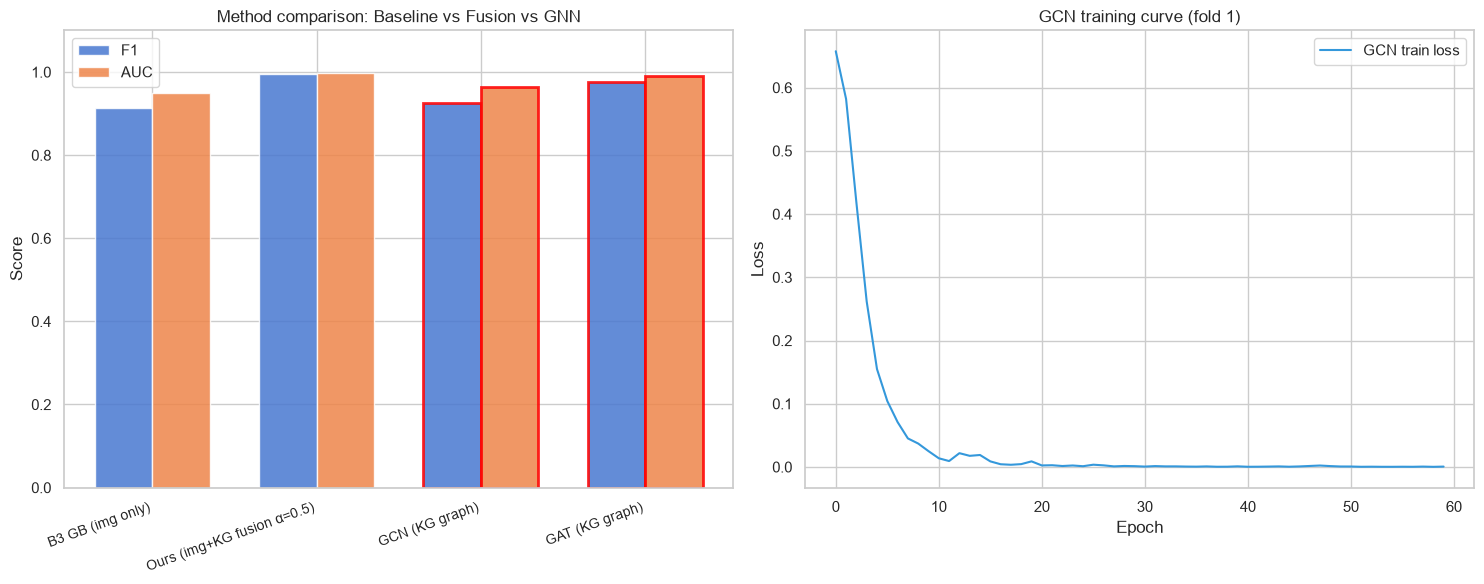

In [7]:

# ═══════════════════════════════════════════════════════════
# Cell 7 — 与之前方法对比
# ═══════════════════════════════════════════════════════════

comparison = {
    "B3 GB (img only)":   {"Accuracy":0.8273,"Precision":0.8771,"Recall":0.9509,"F1":0.9124,"AUC":0.9487},
    "Ours (img+KG fusion α=0.5)": {"Accuracy":0.9942,"Precision":1.0000,"Recall":0.9906,"F1":0.9953,"AUC":0.9988},
    "GCN (KG graph)":     gcn_scores.to_dict(),
    "GAT (KG graph)":     gat_scores.to_dict(),
}
comp_df = pd.DataFrame(comparison).T
comp_df.index.name = "Method"
print("\n=== Full Comparison ===")
print(comp_df.to_string())

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

methods = list(comp_df.index)
x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, comp_df["F1"],  w, label="F1",  alpha=0.85)
bars2 = axes[0].bar(x + w/2, comp_df["AUC"], w, label="AUC", alpha=0.85)
for i, m in enumerate(methods):
    if "GCN" in m or "GAT" in m:
        bars1[i].set_edgecolor("red"); bars1[i].set_linewidth(2)
        bars2[i].set_edgecolor("red"); bars2[i].set_linewidth(2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right", fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_title("Method comparison: Baseline vs Fusion vs GNN")
axes[0].legend()

# 训练曲线（GCN fold 1）
axes[1].plot(gcn_history["train_loss"][0], label="GCN train loss", color="#3498db")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("GCN training curve (fold 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "gnn_comparison.png", dpi=150)
plt.show()



In [8]:

# ═══════════════════════════════════════════════════════════
# Cell 8 — 论文 Table
# ═══════════════════════════════════════════════════════════
print("=" * 70)
print("TABLE: Complete Method Comparison")
print("=" * 70)
header = f"{'Method':<30} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 70)
for method, row in comp_df.iterrows():
    marker = " ◀" if "GNN" in method or "GCN" in method or "GAT" in method else ""
    print(f"{method:<30} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['AUC']:>7.4f}{marker}")

print(f"\nFigure saved: kg_output/gnn_comparison.png")

TABLE: Complete Method Comparison
Method                             Acc    Prec     Rec      F1     AUC
----------------------------------------------------------------------
B3 GB (img only)                0.8273  0.8771  0.9509  0.9124  0.9487
Ours (img+KG fusion α=0.5)      0.9942  1.0000  0.9906  0.9953  0.9988
GCN (KG graph)                  0.9072  0.9277  0.9227  0.9247  0.9641 ◀
GAT (KG graph)                  0.9710  0.9555  1.0000  0.9772  0.9912 ◀

Figure saved: kg_output/gnn_comparison.png
